# Project

# Diamonds Price pridictions


    done by :

       Mohammad Saleem , 0193391
       Tariq shawabkeh , 0201313
            

Import necessary libraries & packages

In [301]:
import sys
assert sys.version_info >= (3,7)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import os
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.svm import SVR

Read the data from the exel file

In [302]:
diamonds = r"C:\Users\moham\Downloads\diamonds.csv"
df = pd.read_csv(diamonds)

Getting some useful information about the data

In [303]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [304]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    50000 non-null  float64
 1   cut      50000 non-null  object 
 2   color    50000 non-null  object 
 3   clarity  50000 non-null  object 
 4   depth    45049 non-null  float64
 5   table    44952 non-null  float64
 6   price    50000 non-null  int64  
 7   x        50000 non-null  float64
 8   y        50000 non-null  float64
 9   z        50000 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 3.8+ MB


we see that there is missing values in 9 columns
and there are int64,object & float64 Dtype

In [305]:
df["carat"].value_counts()

carat
0.30    2412
0.31    2102
1.01    2097
0.70    1843
0.32    1682
        ... 
4.00       1
3.40       1
3.65       1
2.75       1
2.70       1
Name: count, Length: 272, dtype: int64

In [306]:
df["cut"].value_counts()

cut
Ideal        19938
Premium      12806
Very Good    11204
Good          4557
Fair          1495
Name: count, dtype: int64

In [307]:
df["color"].value_counts()

color
G    10452
E     9085
F     8864
H     7711
D     6224
I     5058
J     2606
Name: count, dtype: int64

In [308]:
df["clarity"].value_counts()

clarity
SI1     12115
VS2     11404
SI2      8519
VS1      7579
VVS2     4694
VVS1     3369
IF       1632
I1        688
Name: count, dtype: int64

In [309]:
df.describe(include='all')

,carat,cut,color,clarity,depth,table,price,x,y,z
count,50000.000000,50000,50000,50000,45049.000000,44952.000000,50000.000000,50000.000000,50000.000000,50000.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,19938,10452,12115,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.799444,NaN,NaN,NaN,61.754066,57.454641,3944.805440,5.734403,5.737956,3.541056
std,0.475173,NaN,NaN,NaN,1.432881,2.229656,3997.938105,1.123077,1.145579,0.707065
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2410.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5351.000000,6.540000,6.540000,4.040000


In [310]:
df['cut'].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [311]:
df['color'].unique()

array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object)

Knowing the the numarical column names

In [312]:
df.corr(numeric_only='True')

,carat,depth,table,price,x,y,z
carat,1.000000,0.029419,0.183321,0.921804,0.975037,0.950035,0.952700
depth,0.029419,1.000000,-0.295785,-0.011256,-0.024112,-0.028730,0.095602
table,0.183321,-0.295785,1.000000,0.129166,0.196397,0.183833,0.151649
price,0.921804,-0.011256,0.129166,1.000000,0.884919,0.864393,0.860963
x,0.975037,-0.024112,0.196397,0.884919,1.000000,0.972977,0.970122
y,0.950035,-0.028730,0.183833,0.864393,0.972977,1.000000,0.950030
z,0.952700,0.095602,0.151649,0.860963,0.970122,0.950030,1.000000


Locking for corrolations between the OpenCL & the numarical column

In [313]:
numeric_df = df.select_dtypes(include='number')

ab = numeric_df.corr()

ab["price"].sort_values(ascending=False)

price    1.000000
carat    0.921804
x        0.884919
y        0.864393
z        0.860963
table    0.129166
depth   -0.011256
Name: price, dtype: float64

In [314]:
df.describe()

,carat,depth,table,price,x,y,z
count,50000.000000,45049.000000,44952.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.799444,61.754066,57.454641,3944.805440,5.734403,5.737956,3.541056
std,0.475173,1.432881,2.229656,3997.938105,1.123077,1.145579,0.707065
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2410.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5351.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


# prepair the data


we will train the data only in this assignment

In [315]:
train_set = df.copy()
pricing_without_label=train_set.drop("price",axis = 1)#data withoi label
pricing_label = train_set["price"].copy()

In [316]:
df.info()
#comment waht are the features that have the missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    50000 non-null  float64
 1   cut      50000 non-null  object 
 2   color    50000 non-null  object 
 3   clarity  50000 non-null  object 
 4   depth    45049 non-null  float64
 5   table    44952 non-null  float64
 6   price    50000 non-null  int64  
 7   x        50000 non-null  float64
 8   y        50000 non-null  float64
 9   z        50000 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 3.8+ MB


In [317]:
imputer = SimpleImputer(strategy="median")
columns_to_drop = ["cut","color","clarity","depth"]

# Drop the specified columns

pricing_numarical=pricing_without_label.drop(columns=columns_to_drop, axis = 1)

imputer.fit(pricing_numarical)
#pricing_numarical this that we want to enter it to the numraicl pipeline

SimpleImputer(strategy='median')

In [318]:
imputer.statistics_

array([ 0.7 , 57.  ,  5.7 ,  5.71,  3.53])

In [319]:
pricing_numarical.median().values

array([ 0.7 , 57.  ,  5.7 ,  5.71,  3.53])

### Now we have the numarical data without empty cells ...updated the numarical by adding median that was calculated from fit() to missing cells
we also see that the imputer.statistics and median give the same result

In [320]:
filled_missing_numarical=imputer.transform(pricing_numarical)

### To check : All cells are filled successfully

In [321]:
filled_missing_df_numarical = pd.DataFrame(filled_missing_numarical, columns=pricing_numarical.columns)
filled_missing_df_numarical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   carat   50000 non-null  float64
 1   table   50000 non-null  float64
 2   x       50000 non-null  float64
 3   y       50000 non-null  float64
 4   z       50000 non-null  float64
dtypes: float64(5)
memory usage: 1.9 MB


*All numarical cells are filled*

**# Now we want to take the *categrical* frature alon to handle with them to convert this feature into numarical by using OneHotEncoder**

In [322]:
categrical_columns = ["cut","color","clarity"]
pricing_without_label_catigrical = pricing_without_label[categrical_columns]

we used the most_frequent data to fill the missing data

In [323]:
imputer_for_non_numarical = SimpleImputer(strategy="most_frequent")

imputer_for_non_numarical.fit(pricing_without_label_catigrical)

SimpleImputer(strategy='most_frequent')

In [324]:
Numpy_arr_cat=imputer_for_non_numarical.transform(pricing_without_label_catigrical)

*this returns the array*

### So, We want to convet it into DataFrame

In [325]:
Numpy_arr_categorical_df = pd.DataFrame(Numpy_arr_cat)

In [326]:
Numpy_arr_categorical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       50000 non-null  object
 1   1       50000 non-null  object
 2   2       50000 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB


*see the info again to make sure evreything is correct*

In [327]:
Numpy_arr_categorical_df.describe()

,0,1,2
count,50000,50000,50000
unique,5,7,8
top,Ideal,G,SI1
freq,19938,10452,12115


### We opted for the OneHotEncoder over the OrdinalEncoder because the OrdinalEncoder assigns ordinal values, potentially implying a hierarchy, and organizes features alphabetically.

In [328]:
categrical_encoder= OneHotEncoder()
pricing_catigrical_1Hot = categrical_encoder.fit_transform(Numpy_arr_categorical_df)
pricing_catigrical_1Hot

<50000x20 sparse matrix of type '<class 'numpy.float64'>'
	with 150000 stored elements in Compressed Sparse Row format>

### We used sparse matrix that contains large number of zeros this feature used for  memory mangment system that only stores the addresses of the data ( where location of th 1,s )

convert the spare matrix to dense array :

In [329]:
pricing_catigrical_1Hot.toarray()

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

*To check if there not an missing value :*

In [330]:
Numpy_arr_categorical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       50000 non-null  object
 1   1       50000 non-null  object
 2   2       50000 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB


In [331]:
Numpy_arr_categorical_df.describe()

,0,1,2
count,50000,50000,50000
unique,5,7,8
top,Ideal,G,SI1
freq,19938,10452,12115


In [332]:
Numpy_arr_categorical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       50000 non-null  object
 1   1       50000 non-null  object
 2   2       50000 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB


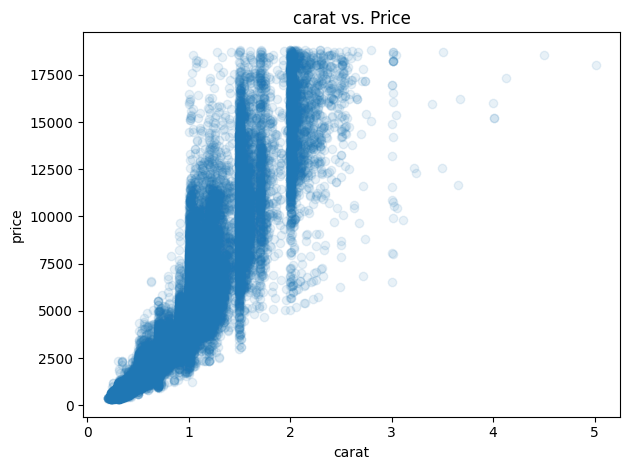

In [333]:
plt.scatter(df['carat'], df['price'], alpha=0.1)
plt.xlabel('carat')
plt.ylabel('price')
plt.title('carat vs. Price')
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

### custom data scaler class that performs both min-max scaling and standard scaling on specified features of a DataFrame, and then applies the transformations to a given dataset. The resulting scaled data is stored in separate DataFrames for min-max scaling and standard scaling.

In [334]:
Numpy_arr_cat_df = pd.DataFrame()
from sklearn.preprocessing import OrdinalEncoder

'''
class CustomScaler (BaseEstimator, TransformerMixin):
    def __init__(self, ordinal_encoder_features, one_hot_encoder_features):

        self.ordinal_encoder_features = ordinal_encoder_features
        self.one_hot_encoder_features = one_hot_encoder_features

        self.ordinal_encoder_cust = OrdinalEncoder()
        self.one_hot_encoder = OneHotEncoder()
        

        


    def fit(self, X, y=None):

        #X = pd.DataFrame(X, columns=self.one_hot_encoder_features + self.ordinal_encoder_features)
        ordinal_data = X[self.ordinal_encoder_features]
        noe_hot_data = X[self.one_hot_encoder_features]
        

        self.ordinal_encoder_cust.fit(ordinal_data.values)
        self.one_hot_encoder.fit(noe_hot_data.values)
        
        return self
    
    def transform(self, X):
        #X = pd.DataFrame(X, columns=self.one_hot_encoder_features + self.ordinal_encoder_features)
        ordinal_data = X[self.ordinal_encoder_features]
        noe_hot_data = X[self.one_hot_encoder_features]
        


        done_ordinal_encoder = self.ordinal_encoder_cust.transform(ordinal_data.values)
        one_hotted_encoder = self.one_hot_encoder.transform(noe_hot_data.values)

        transformed_data = np.concatenate([one_hotted_encoder, done_ordinal_encoder], axis=1)
        transformed_data_df = pd.DataFrame(transformed_data, columns=self.one_hot_encoder_features + self.ordinal_encoder_features)
        return transformed_data_df

# Define the column names
one_hot_encoder_features = ["cut"]
ordinal_encoder_features = ["color", "clarity"]#with labels : , "price"

# Initialize the custom scaler
custom = CustomScaler(ordinal_encoder_features, one_hot_encoder_features)
custom.fit(pricing_without_label_catigrical)#without_labels

# Transform the data
m = custom.transform(pricing_without_label_catigrical)
s = custom.transform(pricing_without_label_catigrical)
'''
'''
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class CustomScaler(BaseEstimator, TransformerMixin):
    def __init__(self, ordinal_encoder_features, one_hot_encoder_features):
        self.ordinal_encoder_features = ordinal_encoder_features
        self.one_hot_encoder_features = one_hot_encoder_features
        self.ordinal_encoder_cust = OrdinalEncoder()
        self.one_hot_encoder = OneHotEncoder()  # Initialize without sparse parameter

    def fit(self, X, y=None):
        ordinal_data = X[self.ordinal_encoder_features]
        noe_hot_data = X[self.one_hot_encoder_features]
        self.ordinal_encoder_cust.fit(ordinal_data.values)
        self.one_hot_encoder.fit(noe_hot_data.values)
        return self
    
    def transform(self, X):
        ordinal_data = X[self.ordinal_encoder_features]
        noe_hot_data = X[self.one_hot_encoder_features]
        done_ordinal_encoder = self.ordinal_encoder_cust.transform(ordinal_data.values)
        one_hotted_encoder = self.one_hot_encoder.transform(noe_hot_data.values).toarray()  # Convert to dense array
        # Ensure the concatenated arrays have the same number of rows
        if one_hotted_encoder.shape[0] == done_ordinal_encoder.shape[0]:
            transformed_data = np.concatenate([one_hotted_encoder, done_ordinal_encoder], axis=1)
            # Create a DataFrame with the appropriate column names
            transformed_data_df = pd.DataFrame(transformed_data, columns=np.concatenate([self.one_hot_encoder.get_feature_names_out(), self.ordinal_encoder_features]))
            return transformed_data_df
        else:
            raise ValueError("The number of rows in one-hot encoded data does not match the number of rows in ordinal encoded data.")

# Define the column names
one_hot_encoder_features = ["cut"]
ordinal_encoder_features = ["color", "clarity"]

# Initialize the custom scaler
custom = CustomScaler(ordinal_encoder_features, one_hot_encoder_features)
# Fit the scaler with your DataFrame
custom.fit(pricing_without_label_catigrical)

# Transform the data
m = custom.transform(pricing_without_label_catigrical)
s = custom.transform(pricing_without_label_catigrical)


'''
class CustomScaler (BaseEstimator, TransformerMixin):
    def __init__(self, min_max_scaling_features, standard_scaling_features):
        self.min_max_scaler = MinMaxScaler()
        self.st_scaler = StandardScaler()
        self.min_max_scaling_features = min_max_scaling_features
        self.standard_scaling_features = standard_scaling_features

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=self.min_max_scaling_features + self.standard_scaling_features)
        min_max_scaling_data = X[self.min_max_scaling_features]
        standard_data = X[self.standard_scaling_features]

        self.min_max_scaler.fit(min_max_scaling_data.values)
        self.st_scaler.fit(standard_data.values)
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X, columns=self.min_max_scaling_features + self.standard_scaling_features)
        min_max_scaling_data = X[self.min_max_scaling_features]
        standard_data = X[self.standard_scaling_features]
        
        min_max_scaled = self.min_max_scaler.transform(min_max_scaling_data.values)
        standard_scaled = self.st_scaler.transform(standard_data.values)
        transformed_data = np.concatenate([min_max_scaled, standard_scaled], axis=1)
        transformed_data_df = pd.DataFrame(transformed_data, columns=self.min_max_scaling_features + self.standard_scaling_features)
        return transformed_data_df

# Define the column names
min_max_scaling_features = ["carat","table","price","x"]
standard_scaling_features = ["depth"]#with labels : , "price"

# Initialize the custom scaler
custom = CustomScaler(min_max_scaling_features, standard_scaling_features)
custom.fit(pricing_numarical)#without_labels

# Transform the data
m = custom.transform(pricing_numarical)
s = custom.transform(pricing_numarical)


C:\Users\moham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\_array_api.py:472: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
C:\Users\moham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\_array_api.py:489: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
C:\Users\moham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\moham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid

### This pipeline is designed to preprocess numerical features.
### It first imputes missing values using the median strategy and then applies custom scaling

In [335]:
from sklearn.preprocessing import StandardScaler
numarical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("customscaler", StandardScaler())
])

We used fit_transform to numarical_pipeline

In [336]:
numarical_pipeline_trans = numarical_pipeline.fit_transform(pricing_numarical)#pricing_numarical , numarical_with_labels
#filled_missing_df_numarical

Applying the OneHotEncoder

In [337]:
cat_pipeline = Pipeline([
("Onehotencoder",OneHotEncoder())#CustomScaler
])

#### filled_missing_df_numarical
#### Numpy_arr_categorical_df

In [338]:
numarical_attributs = list(pricing_numarical)
categrical_attributs = list(pricing_without_label_catigrical)

In [339]:
from sklearn.compose import ColumnTransformer
full_pipeline = ColumnTransformer([
    ("numarical", numarical_pipeline, numarical_attributs),
    ("categorical", cat_pipeline, categrical_attributs),
])

*pricing_prepared : returned as a dense array*

In [340]:
pricing_prepared = full_pipeline.fit_transform(pricing_without_label)#all data numarical + categorical 
pricing_prepared

df = pd.DataFrame(pricing_prepared)

# Save DataFrame to a csv file
df.to_csv('pricing_prepared.csv', index=False)

#### Now the model is trained and now ready to be testes on the some samples from the data itself
#### Now comparing the Predicted Results with the Ground truth to see if given near of acual price of the car

In [341]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(pricing_prepared,pricing_label)

#Now the model is trained and now ready to be testes on the some samples from the data itself

some_data=pricing_without_label.iloc[100:110]
some_labels=pricing_label.iloc[100:110]
some_data_prepared = full_pipeline.transform(some_data)
pricing_prediction = lin_reg.predict(some_data_prepared)
print( "predicted Results of the price of the Daimond :" ,lin_reg.predict(some_data_prepared))

# Now comparing the Predicted Results with the Ground truth to see if given near of acual price of the car

print(" Ground Truth (real price :)",list(some_labels))

predicted Results of the price of the Daimond : [3469.  2910.5 2455.  4064.5 3028.5 3876.  3876.  2778.  3509.  3652.5]
 Ground Truth (real price :) [2761, 2761, 2761, 2761, 2762, 2762, 2762, 2762, 2762, 2762]


In [342]:
from sklearn.metrics import mean_squared_error

lin_rmse = mean_squared_error(some_labels, pricing_prediction,squared=False)

print("MSE of linear Regressor : ",lin_rmse)

MSE of linear Regressor :  788.7098325746928


C:\Users\moham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [343]:
from sklearn.model_selection import cross_val_score
lin_rmses = -cross_val_score(lin_reg, pricing_prepared, pricing_label,scoring="neg_root_mean_squared_error", cv=3)
pd.Series(lin_rmses).describe()

count       3.000000
mean     1593.940430
std       888.256492
min       960.576515
25%      1086.265367
50%      1211.954219
75%      1910.622387
max      2609.290556
dtype: float64

Here we performed a  multiple regression models including Linear Regression, SVR , Decision Tree Regressor, Random Forest Regressor, KNN, ElasticNet, Lasso, and Ridge. It first splits the prepared pricing data into training and testing sets. Then, for each model, it creates a pipeline, performs 3-fold cross-validation on the training data, and calculates the Mean Squared Error (MSE). It stores the average MSE for each model. After evaluating all models, it identifies the model with the lowest MSE as the best model. The name of the best model and its MSE are then printed out. This process helps in determining which regression model performs best for the given data based on the MSE metric.

In [344]:
models = [    
    ('Linear Regression', LinearRegression()),
    ('Decision Tree Regressor', DecisionTreeRegressor()),
    ('Random Forest Regressor', RandomForestRegressor(n_jobs=-1)),
    ('KNN', KNeighborsRegressor()),
    ('ElasticNet', ElasticNet()),
    ('Lasso', Lasso()),
    ('Ridge', Ridge())
]

X_train, X_test, y_train, y_test = train_test_split(pricing_prepared, pricing_label, test_size=0.2, random_state=42)

mse_scores = []
for name, model in models:
    pipeline = make_pipeline(model)
    scores = cross_val_score(pipeline, X_train, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
    mse_scores.append(np.mean(np.abs(scores)))
    print(f'{name}: Average MSE: {np.mean(np.abs(scores))}')

best_model_index = np.argmin(mse_scores)
best_model_name, best_model = models[best_model_index]
print(f'Best model is {best_model_name} with MSE: {mse_scores[best_model_index]}')
#for large amount of data :-300 - 500 -800




Linear Regression: Average MSE: 1316076.144934519
Decision Tree Regressor: Average MSE: 584425.5467562501
Random Forest Regressor: Average MSE: 319340.7909213471
KNN: Average MSE: 547722.214114
ElasticNet: Average MSE: 3004546.8579731598
Lasso: Average MSE: 1311557.4229687476
Ridge: Average MSE: 1315806.10021949
Best model is Random Forest Regressor with MSE: 319340.7909213471


it defines a set of potential hyperparameters to explore. If the best model is a Random Forest Regressor, it will explore various numbers of trees, maximum depths, minimum samples required to split an internal node, and the number of features to consider when looking for the best split

In [345]:
if best_model_name == 'Random Forest Regressor':
    param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10], 'max_features': ['auto', 'sqrt']}
elif best_model_name == 'KNN':
    param_grid = {'n_neighbors': [3, 5, 7, 9]}
elif best_model_name in ['ElasticNet', 'Lasso', 'Ridge']:
    param_grid = {'alpha': [0.1, 0.5, 1.0, 5.0, 10.0]}

performing hyperparameter tuning on the best model identified earlier using Randomized Search Cross Validation and calculate the Mean Squared Error (MSE) and the R-squared statistic

In [346]:
random_search = RandomizedSearchCV(best_model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, n_iter=10)
random_search.fit(X_train, y_train)

# Evaluate the best tuned model
y_pred = random_search.predict(X_test)
print("---------------------------------------------------------------------------------")
print("it reduced from MSE : 320881 to :")
print(f'MSE: {mean_squared_error(y_test, y_pred)}, R^2: {r2_score(y_test, y_pred)}')

C:\Users\moham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
12 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\moham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\moham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packa

---------------------------------------------------------------------------------
it reduced from MSE : 320881 to :
MSE: 287256.5310037778, R^2: 0.9814155158572703


Draw best model

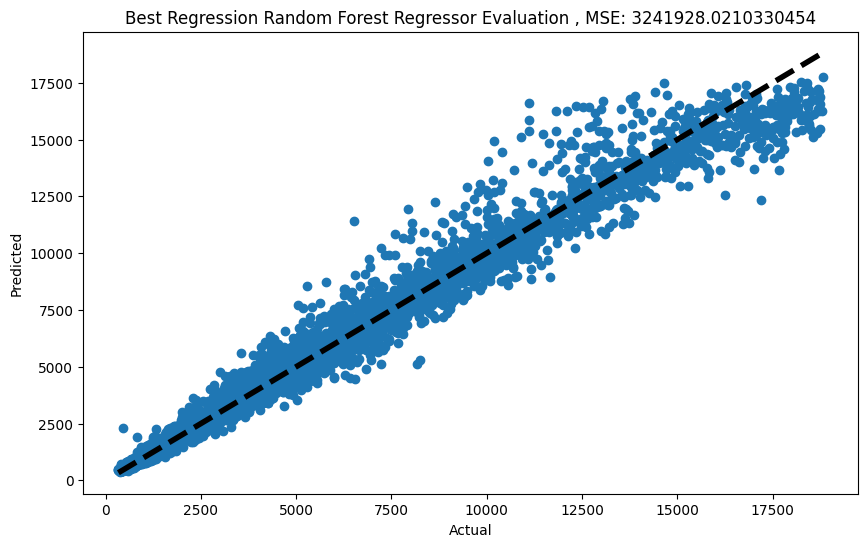

In [347]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Best Regression {best_model_name} Evaluation , MSE: 3241928.0210330454')
plt.show()



Draw evry model we used in different regrssions

Linear Regression: MSE: 1219657.1600601769


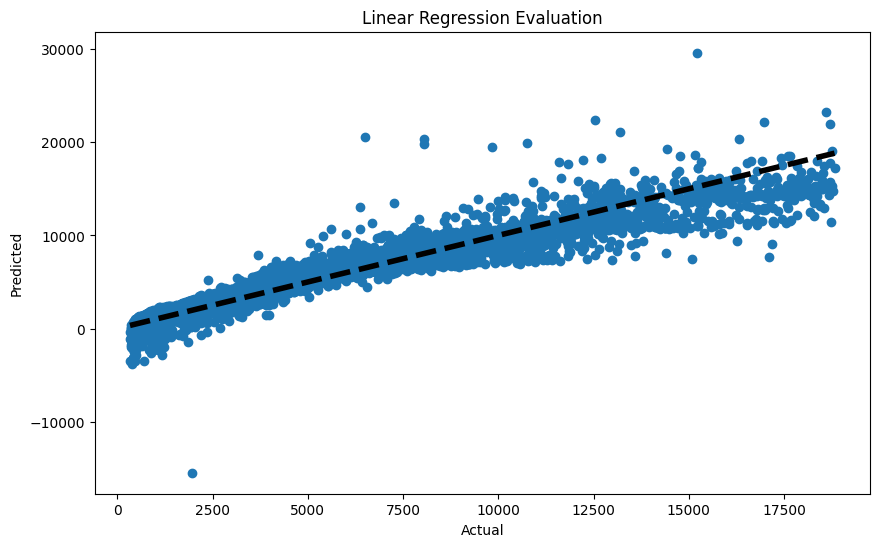

Decision Tree Regressor: MSE: 530191.3372


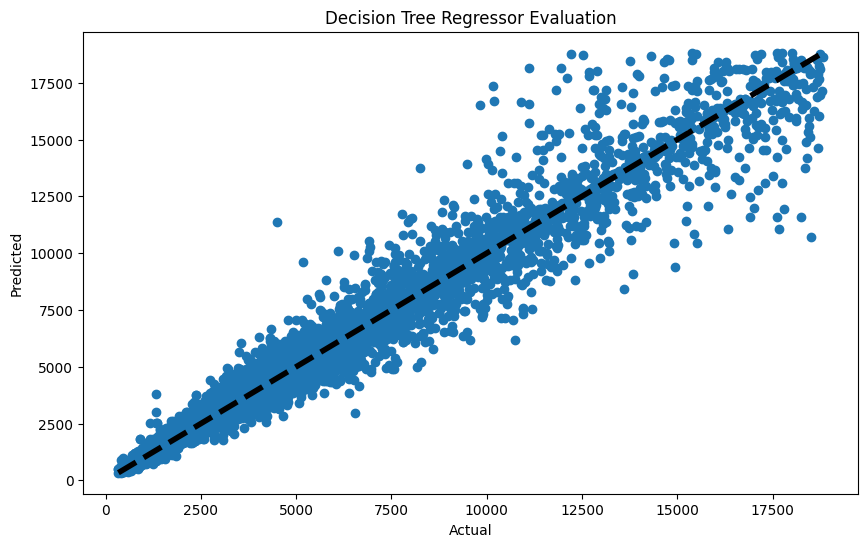

Random Forest Regressor: MSE: 287422.038964635


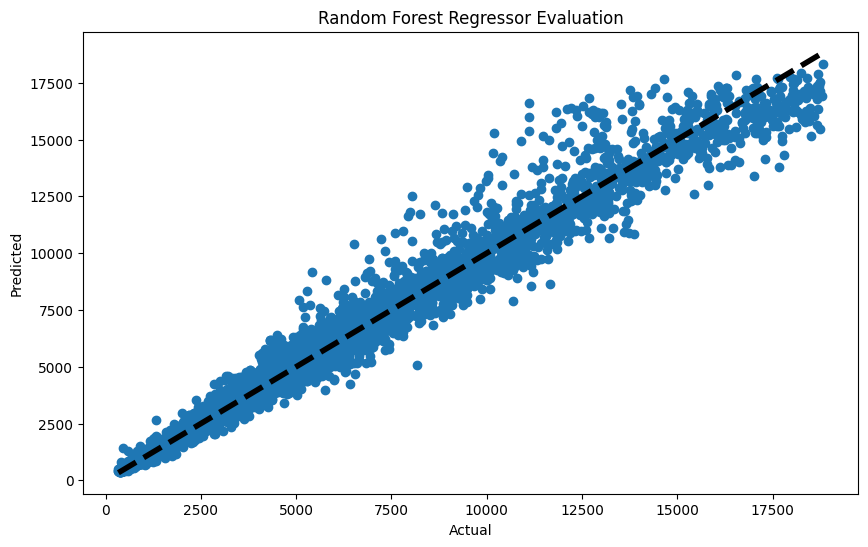

KNN: MSE: 507589.26866400003


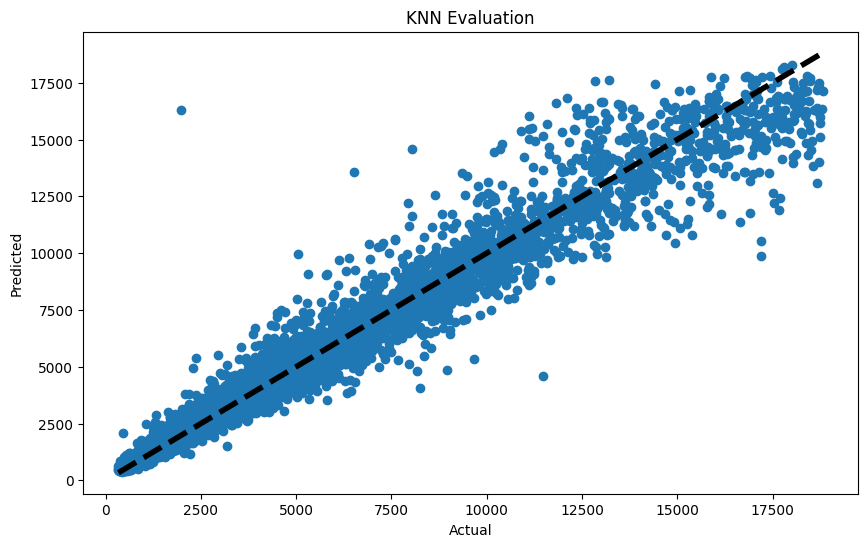

ElasticNet: MSE: 2967607.1203822135


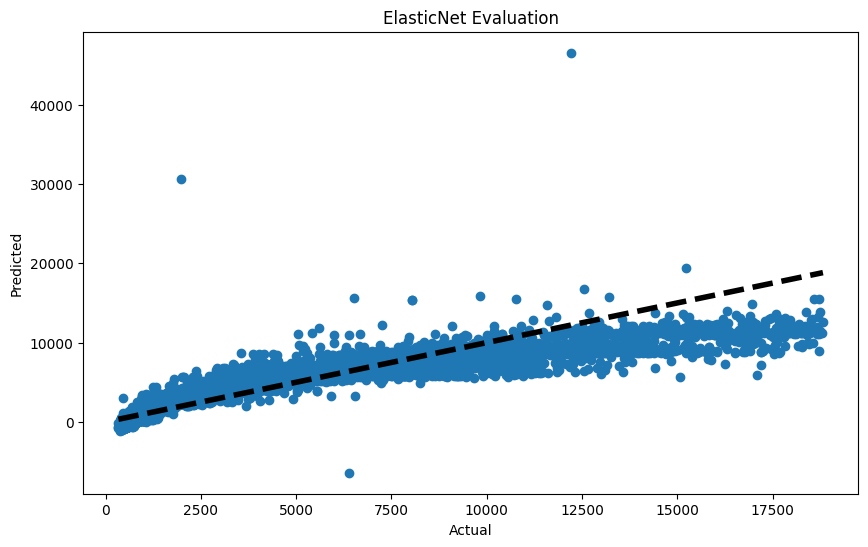

Lasso: MSE: 1216688.8161969886


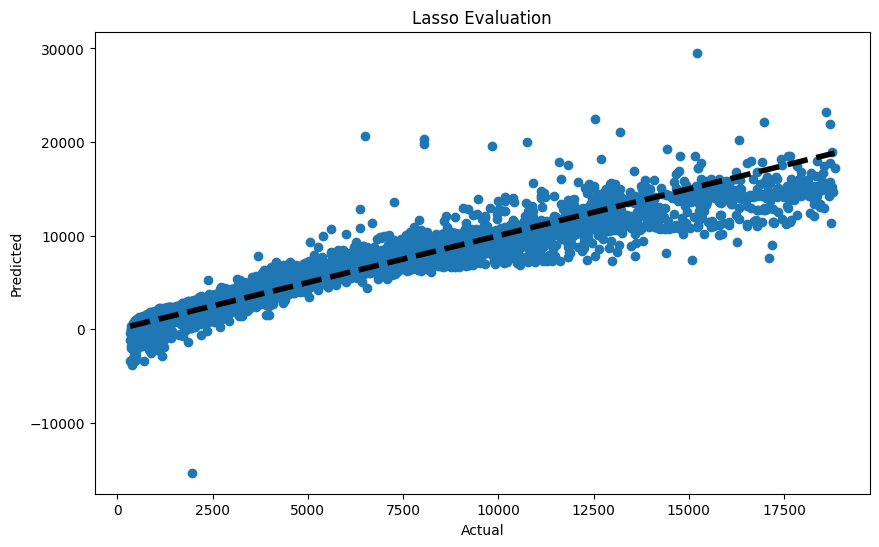

Ridge: MSE: 1219616.5635839715


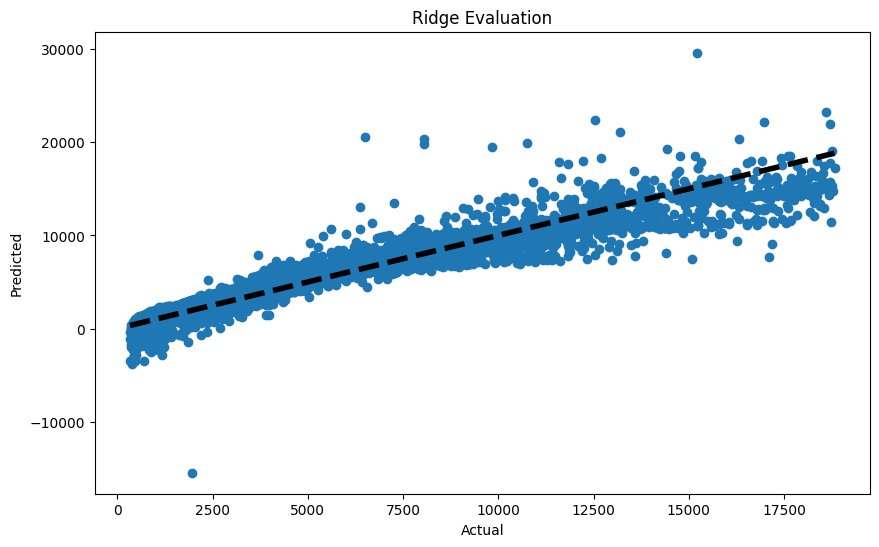

In [348]:
for name, model in models:
    pipeline = make_pipeline(model)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f'{name}: MSE: {mse}')

    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{name} Evaluation')
    plt.show()

### As shown, the best prediction after fine tune is andom Forest Regressor

# Neural Network

In [349]:
import tensorflow as tf
from sklearn.neural_network import MLPRegressor
from tensorflow import keras
#from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout , Normalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler

In [382]:
X_train, X_test, y_train, y_test = train_test_split(pricing_prepared, pricing_label, test_size=0.2, random_state=42)

def build_model(input_shape):
    normalization_layer = Normalization()
    normalization_layer.adapt(X_train)

    model = Sequential([
        normalization_layer,
        Dense(10, activation="relu", kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(10, activation="relu", kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(10, activation="relu", kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(1)
    ])
    return model

input_shape = (X_train.shape[1],)
model = build_model(input_shape)

the goal of the previous code : 

1-Split the dataset into training and testing sets to evaluate the model's performance

2-Define a neural network model architecture with normalization, dropout regularization, and L2 regularization to train on the training 

3-Ensure that the input features are normalized by adapting the normalization layer to the training data.

4-Create a neural network model that can learn patterns from the training data and make predictions on new, unseen data.

5-Once the model is trained, it can be evaluated on the testing set to assess its performance and generalization ability


In [366]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [374]:
history = model.fit(X_train, y_train, epochs=30, batch_size=512, validation_split=0.2, callbacks=[
    tf.keras.callbacks.EarlyStopping(patience=30, restore_best_weights=True)
])

Epoch 1/30


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8250865.5000 - mae: 1739.2341 - val_loss: 2808046.7500 - val_mae: 1098.7744
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8422152.0000 - mae: 1738.9385 - val_loss: 2642620.5000 - val_mae: 1067.6593
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8474069.0000 - mae: 1751.0818 - val_loss: 2861108.7500 - val_mae: 1112.0475
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8535211.0000 - mae: 1753.8776 - val_loss: 2829176.0000 - val_mae: 1108.0316
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8436995.0000 - mae: 1762.1530 - val_loss: 2784427.0000 - val_mae: 1101.1158
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8376219.0000 - mae: 1744.3850 - val_loss: 2741494.5000 - val_mae: 1094.0277
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8406084.0000 - mae: 1766.3651 - val_loss: 2793652.2500 - val_mae: 1106.2756
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8630926.0000 - 

In [354]:
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f'Test MAE: {test_mae}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step - loss: 2893941.2500 - mae: 941.0048
Test MAE: 938.276611328125


In [355]:
def model_builder(hp):
    normalization_layer = Normalization()
    normalization_layer.adapt(X_train)

    model = Sequential([
        normalization_layer,
        Dense(hp.Int('units', min_value=32, max_value=512, step=32), activation="relu"),
        Dropout(0.5),
        Dense(10, activation="relu", kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(10, activation="relu", kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

tuner = kt.Hyperband(model_builder, objective='val_mae', max_epochs=30, factor=3, directory='my_dir', project_name='pricing_model_tuning')
tuner.search(X_train, y_train, epochs=50, validation_split=0.2)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

Reloading Tuner from my_dir\pricing_model_tuning\tuner0.json


In [356]:
model.save('best_pricing_model.h5')

In [357]:
# Load the model
model = tf.keras.models.load_model('best_pricing_model.h5')

# Make predictions
predictions = model.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step


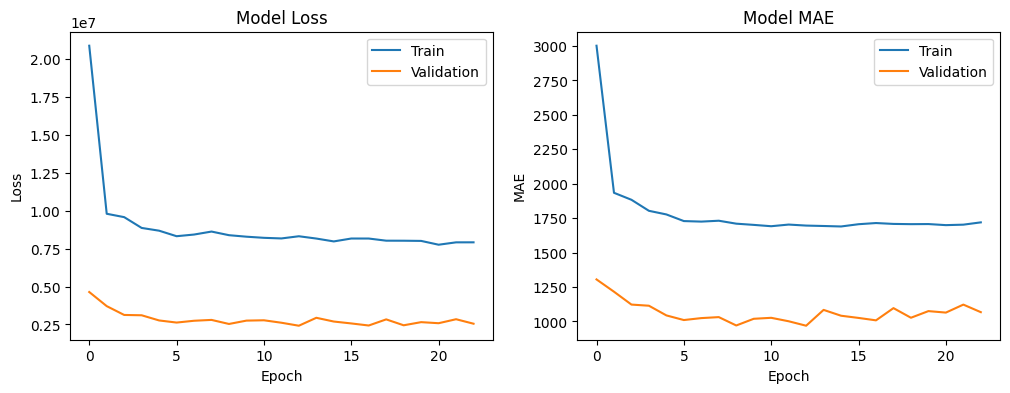

In [358]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    # Plot training & validation loss values
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    # Plot training & validation MAE values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train')
    plt.plot(history.history['val_mae'], label='Validation')
    plt.title('Model MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend(loc='upper right')

    plt.show()

# Assuming `history` is the output of model.fit()
plot_learning_curves(history)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step


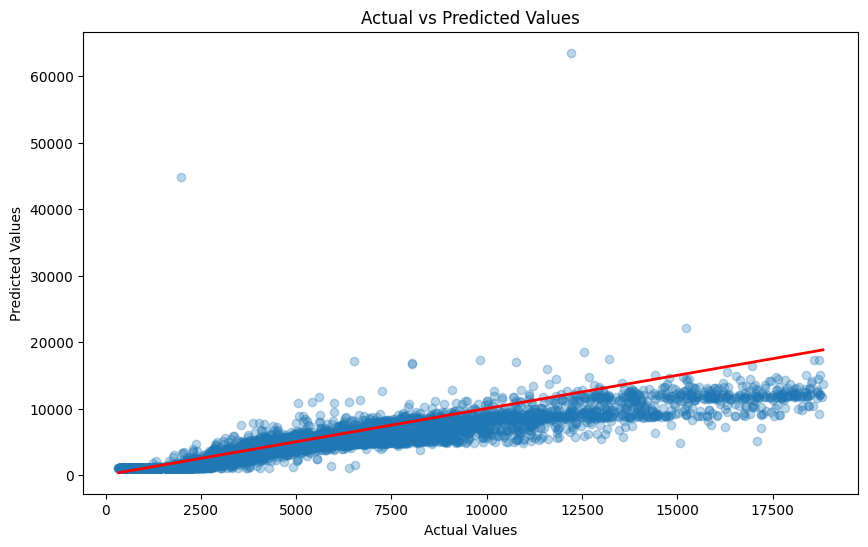

In [359]:
import numpy as np

def plot_predictions_vs_actuals(model, X_test, y_test):
    predictions = model.predict(X_test)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, predictions, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.show()

plot_predictions_vs_actuals(model, X_test, y_test)


  1/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step


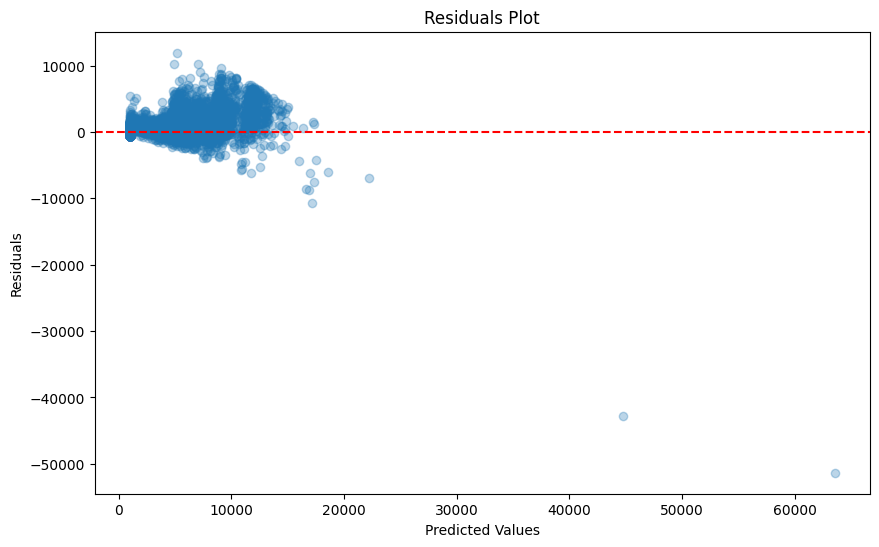

In [360]:
def plot_residuals(model, X_test, y_test):
    predictions = model.predict(X_test)
    residuals = y_test - predictions.flatten()

    plt.figure(figsize=(10, 6))
    plt.scatter(predictions, residuals, alpha=0.3)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title('Residuals Plot')
    plt.show()

plot_residuals(model, X_test, y_test)


In [380]:
from sklearn.ensemble import RandomForestRegressor
importances = None

# Only if you have trained a tree-based model:
# rf_model = RandomForestRegressor().fit(X_train, y_train)
# importances = rf_model.feature_importances_

def plot_feature_importance(importances, feature_names):
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(12, 6))
    plt.title("Feature Importances")
    plt.bar(range(X_train.shape[1]), importances[indices], align="center")
    plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
    plt.xlim([-1, X_train.shape[1]])
    plt.show()

# Replace `importances` and `feature_names` with appropriate values if available
# plot_feature_importance(importances, X_train.columns)
